<br>

# MNIST-Predictive-Pipeline 

## Miniprojeto Módulo 2

<br>

### Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

<br>

In [20]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
import time
from IPython.display import display
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
import seaborn as sns
import visualkeras
from keras.utils import plot_model
from IPython.display import Image
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, classification_report
import tensorflow as tf
import random
import cv2
import glob
import os

In [2]:
# Carregando dataset MNIST

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

# Separando as features da variável alvo
X, y = mnist.data, mnist.target

# Exibindo a dimensionalidade da matriz X e do vetor y
print(f"Dimensionalidade de X (Features): {X.shape}")
print(f"Dimensionalidade de y (Rótulos): {y.shape}")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensionalidade de X (Features): (70000, 784)
Dimensionalidade de y (Rótulos): (70000,)


Separação Antecipada de Features (X) e Variável Alvo (y):

A separação imediata da base de dados entre a matriz de características ($X$, representando os pixels) e o vetor de rótulos ($y$, representando as classes) logo após o carregamento é uma boa prática arquitetural em Machine Learning, justificada por dois motivos técnicos principais:

1. Proteção e Isolamento no Pré-processamento: Garante que as transformações matemáticas exigidas na Fase 2 (como a normalização das features para a escala de 0.0 a 1.0) sejam aplicadas estritamente aos dados de entrada ($X$). Manter as variáveis separadas evita o risco de corromper acidentalmente os rótulos reais ($y$) durante operações matriciais.  

2. Requisito para Divisão Estratificada: Funções de particionamento, como o train_test_split da biblioteca scikit-learn, exigem que os dados e os rótulos sejam passados como argumentos distintos para sincronizar o embaralhamento. Além disso, ter o vetor $y$ isolado no escopo global é um pré-requisito para alimentar o parâmetro de estratificação (stratify=y), assegurando a proporcionalidade correta das classes (dígitos de 0 a 9) nos conjuntos de treino, validação e teste.

Distribuição das amostras por classe (dígito):
Dígito 0: 6903 imagens
Dígito 1: 7877 imagens
Dígito 2: 6990 imagens
Dígito 3: 7141 imagens
Dígito 4: 6824 imagens
Dígito 5: 6313 imagens
Dígito 6: 6876 imagens
Dígito 7: 7293 imagens
Dígito 8: 6825 imagens
Dígito 9: 6958 imagens


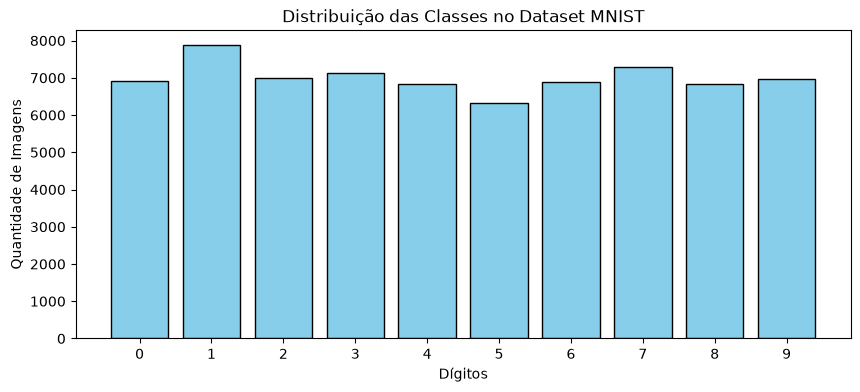

In [3]:
# Verificando balanceamento do dataset

# Analisando a distribuição das classes (dígitos de 0 a 9)
classes, contagens = np.unique(y, return_counts=True)

print("Distribuição das amostras por classe (dígito):")
for classe, contagem in zip(classes, contagens):
    print(f"Dígito {classe}: {contagem} imagens")

# Visualização gráfica
plt.figure(figsize=(10, 4))
plt.bar(classes, contagens, color='skyblue', edgecolor='black')
plt.title("Distribuição das Classes no Dataset MNIST")
plt.xlabel("Dígitos")
plt.ylabel("Quantidade de Imagens")
plt.show()

In [4]:
# Calculando a dispersão estatística da distribuição de classes
media_amostras = np.mean(contagens)
desvio_padrao = np.std(contagens)
coeficiente_variacao = (desvio_padrao / media_amostras) * 100

print(f"Média de amostras por classe: {media_amostras:.0f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}")
print(f"Coeficiente de Variação (CV): {coeficiente_variacao:.2f}%")

Média de amostras por classe: 7000
Desvio Padrão: 378.82
Coeficiente de Variação (CV): 5.41%


Um coeficiente de variação igual a 5.41% é considerado um indicador de baixa dispersão e alta homogeneidade estrutural. Assim, confirma-se que o dataset está balanceado.

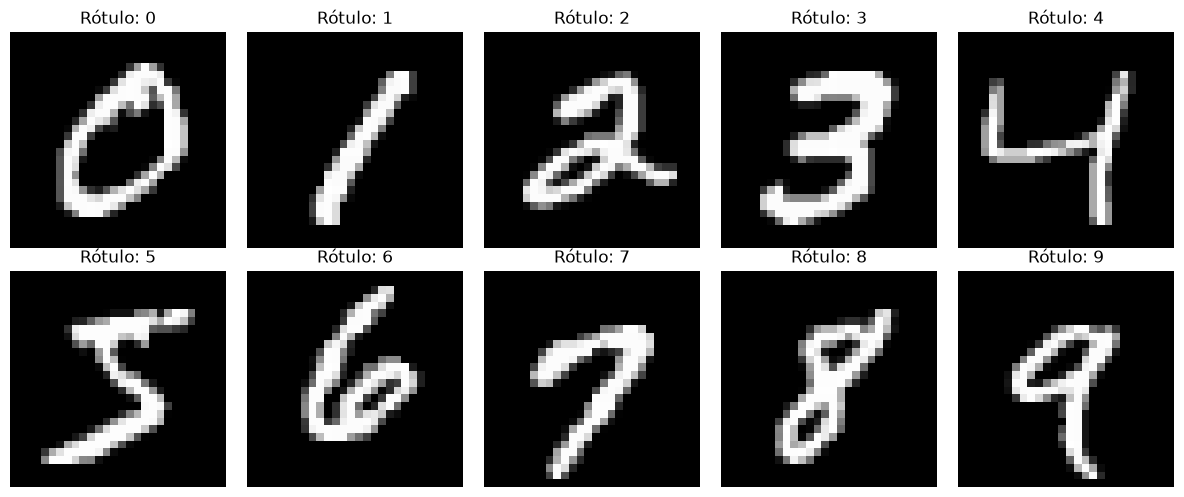

In [5]:
# Exemplos de imagens de cada dígito com seus respectivos rótulos

# Criando uma figura com 2 linhas e 5 colunas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Iterando sobre os dígitos de 0 a 9 para buscar o primeiro exemplo de cada
for classe in range(10):
    # Encontra o índice da primeira ocorrência da classe atual
    indice_imagem = np.where(y == str(classe))[0][0]
    
    # Extrai o vetor de 784 features e remodela para matriz 28x28
    imagem_28x28 = X[indice_imagem].reshape(28, 28)
    
    # Define a posição do subplot (linha e coluna)
    linha = classe // 5
    coluna = classe % 5
    
    # Plota a imagem em escala de cinza
    axes[linha, coluna].imshow(imagem_28x28, cmap='gray')
    axes[linha, coluna].set_title(f"Rótulo: {classe}")
    axes[linha, coluna].axis('off')

plt.tight_layout()
plt.show()

### Interpretação da Estrutura dos Dados


<u>Escala de Intensidade de Pixels (0 a 255)</u>

As imagens do dataset MNIST são monocromáticas (escala de cinza). Computacionalmente, isso significa que cada pixel não possui múltiplos canais de cor (como o RGB), mas sim um único valor numérico inteiro que varia de 0 a 255. Nesta escala de intensidade matemática:

1. O valor 0 representa a ausência total de luz (preto absoluto, geralmente o fundo da imagem).
2. O valor 255 representa a intensidade luminosa máxima (branco absoluto, geralmente o traço principal do dígito).
3. Os valores intermediários (1 a 254) formam as transições suaves e as bordas (tons de cinza).


<u>Representação Vetorial (Transformação de $28\times28$ para 784 features)</u>

Embora a natureza geométrica original de cada imagem seja uma grade bidimensional (uma matriz de 28 linhas por 28 colunas), os algoritmos clássicos de Machine Learning (como SVM e Random Forest) exigem que os dados de entrada sejam unidimensionais.
Para resolver isso, a matriz $28\times28$ passa por um processo de "achatamento" (flattening), onde as linhas de pixels são concatenadas lado a lado. Como $28 \times 28 = 784$, o resultado é um único vetor contendo 784 posições. Portanto, cada "feature" (coluna no nosso conjunto $X$) representa a intensidade de luz de um pixel específico localizado em um ponto exato do desenho original. 

<br>

### Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

<br>

In [6]:
# Como vamos testar alguns hiperparâmetros no treinamento dos modelos,
# optou-se por separar os dados de validação dos dados de teste a fim de evitar vazamento de dados

# Divisão Estratificada (80% Treino, 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print("--- DIVISÃO DOS DADOS ---")
print(f"Treino (80%): {X_train.shape[0]} amostras")
print(f"Teste (20%): {X_test.shape[0]} amostras")

--- DIVISÃO DOS DADOS ---
Treino (80%): 56000 amostras
Teste (20%): 14000 amostras


In [7]:
# Normalização / Escalonamento para o intervalo [0.0, 1.0]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print("\n--- NORMALIZAÇÃO ---")
print(f"Valor máximo original (Treino): {X_train.max()}")
print(f"Valor máximo normalizado (Treino): {X_train_norm.max()}")


--- NORMALIZAÇÃO ---
Valor máximo original (Treino): 255
Valor máximo normalizado (Treino): 1.0


### A Importância da Normalização

A etapa de normalização dos pixels (redimensionamento para o intervalo contínuo de 0.0 a 1.0) é um pré-requisito matemático crucial para o desempenho dos algoritmos de aprendizado de máquina escolhidos:

1. Convergência de Modelos de Otimização e Redes Neurais: Modelos que dependem do algoritmo de Gradiente Descendente (como a Regressão Logística e o Perceptron Multicamadas - MLP) convergem de forma muito mais eficiente quando as variáveis de entrada estão em uma escala padronizada e pequena. Valores não normalizados (como 255) causam passos oscilantes e desproporcionais na atualização dos pesos, podendo impedir que o modelo alcance o mínimo global da função de perda.

2. Modelos Baseados em Distâncias Métricas: Caso utilizemos algoritmos que calculam similaridade espacial (como o KNN ou SVM), a normalização é obrigatória. Como os cálculos dependem da Distância Euclidiana entre os pontos, variáveis não escalonadas distorcem a métrica, prejudicando a capacidade geométrica do modelo de separar as classes no hiperplano.

<br>

### Fase 3: Implementação e Treinamento dos 3 Modelos

<br>

### Modelos Clássicos

In [8]:
# # 1. Configuração do dicionário de modelos clássicos e seus hiperparâmetros
# modelos_classicos = {
#     "Regressão Logística": {
#         "estimador": LogisticRegression(solver='saga', random_state=42),
#         "parametros": {
#             "C": [0.1, 1.0],
#             "max_iter": [100, 200]
#         }
#     },
#     "Random Forest": {
#         "estimador": RandomForestClassifier(random_state=42),
#         "parametros": {
#             "n_estimators": [50, 100],
#             "max_depth": [10, None]
#         }
#     }
# }

# melhores_modelos = {}

# print("--- TREINAMENTO DE MODELOS CLÁSSICOS (GridSearchCV) ---")

# # 2. Laço de treinamento e busca automatizada
# for nome, config in modelos_classicos.items():
#     print(f"\nIniciando busca para: {nome}...")
#     inicio = time.time()
    
#     # cv=3 divide o treino em 3 dobras para validação cruzada interna
#     grid = GridSearchCV(config["estimador"], config["parametros"], cv=3, n_jobs=-1, verbose=1)
#     grid.fit(X_train_norm, y_train)
    
#     fim = time.time()
#     tempo_execucao = (fim - inicio) / 60
    
#     melhores_modelos[nome] = grid.best_estimator_
    
#     print(f"Melhores parâmetros: {grid.best_params_}")
#     print(f"Tempo de treinamento: {tempo_execucao:.2f} minutos")

In [9]:
# Na tentativa inicial de realizar o treinamento com validação cruzada em todo dataset de treino, o modelo travou.
# Assim, optou-se por realizar uma subamostragem apenas para encontrar os melhores hiperparâmetros.
# O treinamento final será feito com o dataset de treino completo.

# 1. Subamostragem para Busca (10k)
print("--- 1. CRIANDO SUBAMOSTRA PARA GRIDSEARCH ---") 
X_busca, y_busca = resample(
    X_train_norm, y_train,
    replace=False,      # <--- Garante imagens únicas
    n_samples=10000,    # <--- Extrai 10.000 amostras mantendo a proporção exata de cada dígito
    stratify=y_train,   # <--- Garante que a divisão entre dados de treino e teste mantenha a mesma proporção das classes
    random_state=42     # <--- Semente de aleatoriedade
)
print(f"Tamanho da amostra: {X_busca.shape[0]} imagens únicas\n")

# 2. Configuração dos Modelos Clássicos
modelos_classicos = {
    "Regressão Logística": {
        "estimador": LogisticRegression(solver='lbfgs', random_state=42),    # A troca do solver 'saga' pelo 'lbfgs' foi realizada para otimizar o custo computacional
        "parametros": {
            "C": [0.1, 1.0],
            "max_iter": [50, 100]
        }
    },
    "Random Forest": {
        "estimador": RandomForestClassifier(random_state=42),
        "parametros": {
            "n_estimators": [50, 100],
            "max_depth": [10, None]
        }
    }
}

melhores_modelos = {}

# 3. Laço Único: Busca, Histórico e Seleção
print("--- 2. OTIMIZAÇÃO DE HIPERPARÂMETROS (Subamostra) ---")

for nome, config in modelos_classicos.items():
    print(f"\n>> Analisando: {nome}...")
    inicio = time.time()
    
    # verbose=0 silencia os logs poluídos do Scikit-Learn
    grid = GridSearchCV(config["estimador"], config["parametros"], cv=3, n_jobs=2, verbose=0)
    grid.fit(X_busca, y_busca)
    
    fim = time.time()
    melhores_modelos[nome] = grid.best_estimator_
    
    print(f"Melhores parâmetros: {grid.best_params_}")
    print(f"Tempo de busca: {(fim - inicio) / 60:.2f} minutos")
    
    # Extração imediata do histórico (sem retreinar)
    df_resultados = pd.DataFrame(grid.cv_results_)
    colunas_param = [col for col in df_resultados.columns if col.startswith('param_')]
    colunas_exibicao = colunas_param + ['mean_fit_time', 'mean_test_score', 'rank_test_score']
    df_tabela = df_resultados[colunas_exibicao].sort_values(by='rank_test_score')
    
    display(df_tabela)

# 4. Treinamento Definitivo
print("\n--- 3. TREINAMENTO FINAL NA BASE COMPLETA (80%) ---")
modelos_treinados = {}

for nome, modelo in melhores_modelos.items():
    print(f"\n\nTreinando {nome} com os hiperparâmetros campeões...")
    inicio = time.time()
    
    modelo.fit(X_train_norm, y_train)
    
    fim = time.time()
    modelos_treinados[nome] = modelo
    print(f"{nome} concluído em {(fim - inicio) / 60:.2f} minutos.")
    

--- 1. CRIANDO SUBAMOSTRA PARA GRIDSEARCH ---
Tamanho da amostra: 10000 imagens únicas

--- 2. OTIMIZAÇÃO DE HIPERPARÂMETROS (Subamostra) ---

>> Analisando: Regressão Logística...
Melhores parâmetros: {'C': 0.1, 'max_iter': 100}
Tempo de busca: 0.49 minutos


,param_C,param_max_iter,mean_fit_time,mean_test_score,rank_test_score
1,0.1,100,3.407488,0.907000,1
0,0.1,50,2.016037,0.906799,2
2,1.0,50,1.878762,0.899600,3
3,1.0,100,3.231019,0.895800,4



>> Analisando: Random Forest...
Melhores parâmetros: {'max_depth': None, 'n_estimators': 100}
Tempo de busca: 0.40 minutos


,param_max_depth,param_n_estimators,mean_fit_time,mean_test_score,rank_test_score
3,None,100,3.569961,0.9427,1
2,None,50,1.982768,0.9369,2
1,10,100,3.461158,0.9349,3
0,10,50,2.133503,0.9294,4



--- 3. TREINAMENTO FINAL NA BASE COMPLETA (80%) ---


Treinando Regressão Logística com os hiperparâmetros campeões...


c:\Users\Raphael\Documents\MNIST-Predictive-Pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Regressão Logística concluído em 1.28 minutos.


Treinando Random Forest com os hiperparâmetros campeões...
Random Forest concluído em 0.62 minutos.


### Documentação - Treinamento dos modelos clássicos

A tentativa inicial de rodar todas as combinações de hiperparâmetros na base completa (56.000 imagens) exigiu muito processamento e travou o sistema. A solução estruturada no código divide o processo em duas grandes etapas: uma busca rápida por configurações ideais em uma amostra menor e o treinamento definitivo na base completa.

Passo 1: Subamostragem Inteligente

- A função `resample` cria um "mini-dataset" de apenas 10.000 imagens para acelerar os testes.

- O parâmetro `replace=False` impede o sorteio de imagens repetidas.

- O parâmetro crucial é o `stratify=y_train`: ele força a amostra a manter a proporção exata do dataset original. Se a base inteira tem 10% de números "8", a amostra de 10.000 também terá exatamente 10% de números "8", garantindo que a redução de dados não crie um viés ou desbalanceamento.

Passo 2: Configuração do Dicionário (A Malha de Testes)

- O código organiza um dicionário (`modelos_classicos`) que funciona como um roteiro de testes.

- Os modelos clássicos escolhidos foram: Regressão Logística (adotado como modelo linear de base) e Random Forest (lida muito bem com imagens sem precisar de configurações complexas)

    - Regressão Logística:

        - Motor matemático `lbfgs`: melhor custo computacional. Gasta menos memória e performa melhor em dataset grandes.

        - `C` (0.1 e 1.0): controla o quanto penalizamos o modelo por criar regras complexas demais. O valor `1.0` é o padrão da ferramenta (equilíbrio normal). O valor `0.1` aplica uma punição mais forte, forçando o modelo a ser mais simples. Testar ambos nos permite ver se os dados preferem uma abordagem mais flexível ou mais estrita.

        - `max_iter` (50 e 100): limite de tentativas (passos) que o algoritmo tem para encontrar a fórmula matemática ideal. Valores como `50` e `100` são intencionalmente baixos para priorizar a velocidade de processamento no computador, mesmo que o algoritmo pare antes de chegar à perfeição matemática.

    - Random Forest:

        - `n_estimators` (50 e 100): quantidade de árvores que farão parte da votação para adivinhar o dígito. Testamos um valor menor (50) para verificar se o modelo aprende rápido gastando pouco processamento. O valor maior (100) serve para checar se o aumento de árvores (mais "opiniões") melhora a taxa de acerto o suficiente para justificar o tempo extra de cálculo no computador.

        - `max_depth` (10 e None): define até onde cada árvore pode crescer. O valor 10 corta o crescimento cedo, forçando o modelo a aprender apenas os traços mais grossos dos números (evitando overfitting). O valor None deixa a árvore crescer livremente até decorar cada pixel do treino, o que gasta mais memória, mas testa o limite máximo de aprendizado do modelo.

Passo 3: Busca Automatizada (`GridSearchCV`)

- Mecânica do GridSearchCV: Essa ferramenta não treina apenas um modelo, mas cria uma "malha" de testes. Ela cruza as combinações (ex: `C=0.1` com `max_iter=50`), separa os dados em pedaços, treina em uma parte e faz uma prova cega na outra. A pontuação `mean_test_score` é a média das notas dessas provas, garantindo que a melhor configuração não foi escolhida por pura sorte.

- Métrica preliminar: optou-se pela acurácia (taxa de acerto global) em vez do F1-Score nesta fase porque o dataset MNIST está balanceado. Não há "classes raras" para distorcer a nota.

- O laço `for` roda a ferramenta de busca exclusivamente na base reduzida (`X_busca` e `y_busca`).

- O parâmetro `cv=3` divide as 10.000 imagens em três pedaços. Ele treina o modelo em dois pedaços e aplica uma prova cega no terceiro.

- O código extrai os resultados e monta uma tabela visual. O Pandas organiza as linhas pelo `rank_test_score`.

- Resultados da Busca: A Regressão Logística obteve a melhor nota com `C=0.1` e `max_iter=100` (Acurácia provisória de 0.907). A Random Forest obteve o melhor resultado rodando livre, com `max_depth=None` e `n_estimators=100` (Acurácia provisória de 0.942).

Passo 4: Treinamento Definitivo

- Com os testes concluídos, o código ignora a subamostra temporária e passa a treinar os modelos na base de dados original completa.

- Ele pega apenas os parâmetros "campeões" do Passo 3 e injeta na função `.fit()` contra o `X_train_norm` inteiro (56.000 imagens). Isso garante que os modelos aprendam com a totalidade dos dados usando a melhor estratégia possível.

- O `ConvergenceWarning` exibido na saída da Regressão Logística confirma que o algoritmo bateu o teto das 100 tentativas matemáticas (`max_iter=100`) escolhidas pelo GridSearch e parou o cálculo, economizando tempo sem sacrificar a precisão estabelecida.

### Rede Neural

--- CONVERTENDO RÓTULOS PARA INTEIROS ---
Tipo atual do y_train: int8

--- CONSTRUINDO A REDE NEURAL (MLP) ---


c:\Users\Raphael\Documents\MNIST-Predictive-Pipeline\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


--- INICIANDO O TREINAMENTO ---
Epoch 1/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9186 - loss: 0.2870 - val_accuracy: 0.9486 - val_loss: 0.1750
Epoch 2/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9616 - loss: 0.1304 - val_accuracy: 0.9601 - val_loss: 0.1334
Epoch 3/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9740 - loss: 0.0883 - val_accuracy: 0.9678 - val_loss: 0.1068
Epoch 4/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9810 - loss: 0.0649 - val_accuracy: 0.9685 - val_loss: 0.1001
Epoch 5/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9837 - loss: 0.0517 - val_accuracy: 0.9688 - val_loss: 0.1033
Epoch 6/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9876 - loss: 0.0391 - val_accuracy: 0.9713 - val_loss: 0.0946
Epoch 7/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9909 - loss: 0.0312 - val_accuracy: 0.9682 - val_loss: 0.1052
Epoch 8/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - a

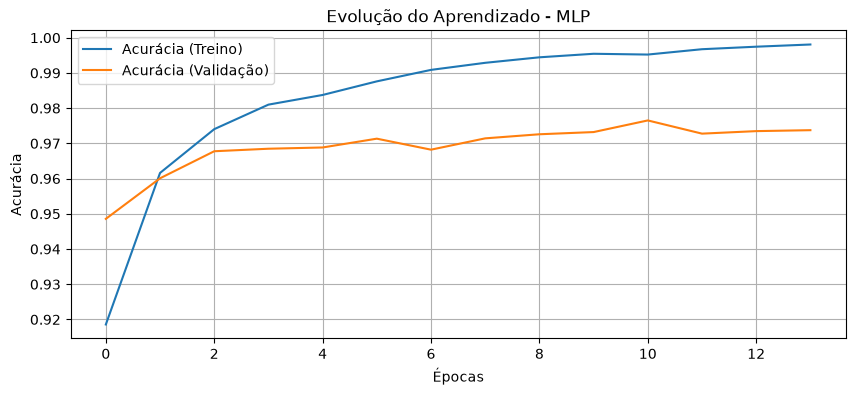


Gerando diagrama arquitetural...


c:\Users\Raphael\Documents\MNIST-Predictive-Pipeline\.venv\Lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


In [10]:
print("--- CONVERTENDO RÓTULOS PARA INTEIROS ---")
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
print(f"Tipo atual do y_train: {y_train.dtype}")

print("\n--- CONSTRUINDO A REDE NEURAL (MLP) ---")
# 1. Arquitetura do Modelo
modelo_mlp = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

# 2. Compilação (Regras de Aprendizado)
modelo_mlp.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
modelo_mlp.summary()

# 3. Treinamento Otimizado com Parada Antecipada
print("\n--- INICIANDO O TREINAMENTO ---")

# Otimização: Trava de segurança contra overfitting
parada_antecipada = EarlyStopping(
    monitor='val_accuracy', 
    patience=3,                 # Tolerância: espera 3 épocas sem melhoria antes de parar
    restore_best_weights=True   # Ao parar, reverte para a época que teve a maior nota
)

historico = modelo_mlp.fit(
    X_train_norm, 
    y_train, 
    epochs=15, 
    batch_size=32,      # <--- A rede neural processará lotes de 32 imagens por vez
    validation_split=0.2,
    callbacks=[parada_antecipada] # Injeção da trava no treinamento
)

# 4. Gráfico de Aprendizado
plt.figure(figsize=(10, 4))
plt.plot(historico.history['accuracy'], label='Acurácia (Treino)')
plt.plot(historico.history['val_accuracy'], label='Acurácia (Validação)')
plt.title('Evolução do Aprendizado - MLP')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

# 5. Renderização Arquitetural (VisualKeras)
print("\nGerando diagrama arquitetural...")
for camada in modelo_mlp.layers:
    camada.output_shape = tuple(camada.output.shape)

imagem_vk = visualkeras.layered_view(
    modelo_mlp, 
    to_file='arquitetura_visualkeras.png', 
    scale_xy=2, 
    scale_z=1, 
    max_z=100
)
display(imagem_vk)

### Documentação - Treinamento Rede Neural (MLP)

- Conversão de Tipagem: Os algoritmos do Scikit-Learn realizam a conversão de textos para números internamente, mas o Keras exige tensores numéricos nativos. A conversão das variáveis alvo (`y`) para inteiros de 8 bits (`int8`) adequa os dados para a matemática da rede gastando o mínimo de memória RAM possível.

- Definição da Arquitetura: A topologia do Perceptron Multicamadas (MLP) foi construída de forma direta. A camada oculta recebe as 784 dimensões (pixels) e processa os padrões morfológicos usando 128 neurônios com ativação ReLU (que zera os sinais de pixels inativos de fundo). A camada de saída afunila os cálculos para 10 neurônios, utilizando a função Softmax para converter os sinais brutos em um espectro probabilístico (porcentagem de chance para cada dígito).

- Motor de Compilação: O modelo foi compilado utilizando o otimizador `adam` por sua capacidade de ajustar dinamicamente os saltos matemáticos. A função de perda definida foi a `sparse_categorical_crossentropy`, mandatória para classificar múltiplas categorias quando os gabaritos são números inteiros (não-binarizados).

- Treinamento Dinâmico (Early Stopping): Em vez de forçar o processador a executar as 15 épocas cegamente, o treinamento foi ancorado a um callback de monitoramento. O algoritmo reserva 20% das imagens para validação cega (`validation_split=0.2`). Se a acurácia de validação parar de subir por 3 épocas consecutivas, o treinamento é interrompido e os pesos matemáticos retornam automaticamente para a época de maior desempenho, poupando processamento e blindando o modelo contra overfitting.

- Geração de Relatórios Visuais: O pipeline finaliza plotando as curvas de aprendizado sobrepostas para análise de divergência e aplica um patch de compatibilidade nas propriedades internas do Keras 3 para extrair e exibir o diagrama em blocos 3D das camadas via VisualKeras.

- Exclusão do GridSearchCV: Não usamos a malha de testes automática na Rede Neural devido ao peso computacional. Fazer dezenas de combinações cruzadas treinando 15 épocas repetidas vezes faria o notebook travar ou levar dias para concluir. O ajuste visual pelas curvas de aprendizado foi a solução mais viável e didática.

<br>

### Fase 4: Avaliação Comparativa de Desempenho

<br>

--- FASE 4: AVALIAÇÃO COMPARATIVA DE DESEMPENHO ---

>> Relatório de Classificação: Regressão Logística
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.97      0.96      1575
           2       0.92      0.89      0.91      1398
           3       0.90      0.89      0.90      1428
           4       0.93      0.92      0.93      1365
           5       0.88      0.87      0.88      1263
           6       0.93      0.96      0.95      1375
           7       0.94      0.95      0.94      1459
           8       0.90      0.88      0.89      1365
           9       0.90      0.90      0.90      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000


>> Relatório de Classificação: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.99   

,Modelo,Acurácia Global,Precisão (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Regressão Logística,0.9215,0.9212,0.9215,0.9213
1,Random Forest,0.9672,0.9672,0.9672,0.9672
2,Rede Neural (MLP),0.9772,0.9773,0.9772,0.9772


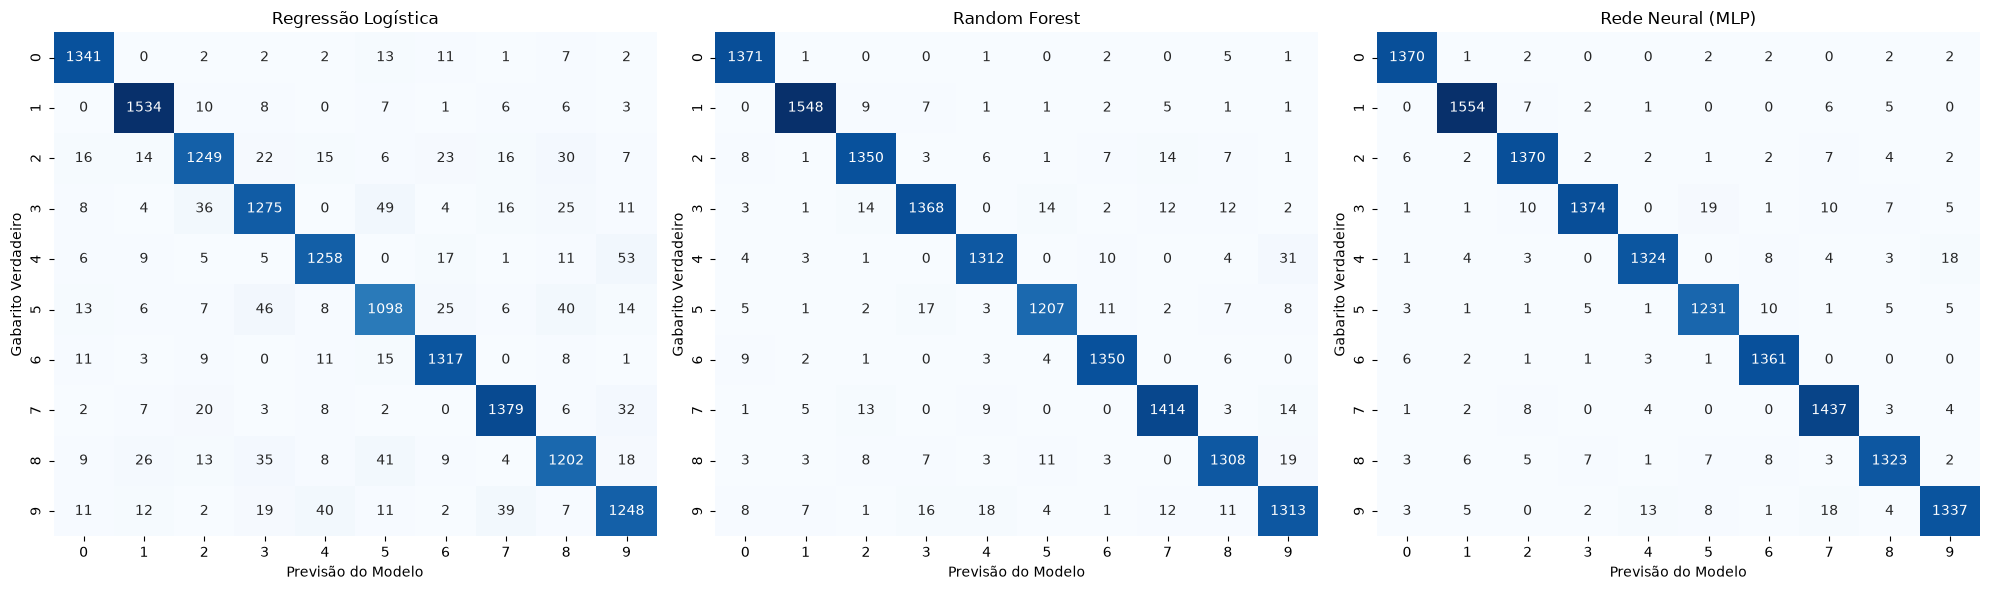

In [11]:
print("--- FASE 4: AVALIAÇÃO COMPARATIVA DE DESEMPENHO ---")

# 1. Gerando previsões (com conversão para int8 para alinhamento de tipos)
y_pred_lr = modelos_treinados['Regressão Logística'].predict(X_test_norm).astype(np.int8)
y_pred_rf = modelos_treinados['Random Forest'].predict(X_test_norm).astype(np.int8)

previsoes_prob = modelo_mlp.predict(X_test_norm, verbose=0)
y_pred_mlp = np.argmax(previsoes_prob, axis=1).astype(np.int8)

dicionario_previsoes = {
    'Regressão Logística': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Rede Neural (MLP)': y_pred_mlp
}

# 2. Extração de Métricas e Geração de Relatórios
resultados = []

for nome, y_pred in dicionario_previsoes.items():
    # Cálculo para a tabela
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    resultados.append({
        'Modelo': nome,
        'Acurácia Global': f"{acc:.4f}",
        'Precisão (Weighted)': f"{prec:.4f}",
        'Recall (Weighted)': f"{rec:.4f}",
        'F1-Score (Weighted)': f"{f1:.4f}"
    })
    
    # Exibição do relatório individual
    print(f"\n>> Relatório de Classificação: {nome}")
    print(classification_report(y_test, y_pred))

# 3. Tabela Consolidada
print("\n--- Tabela Consolidada ---")
df_comparativo = pd.DataFrame(resultados)
display(df_comparativo)

# 4. Matrizes de Confusão Lado a Lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (nome, y_pred) in zip(axes, dicionario_previsoes.items()):
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{nome}')
    ax.set_ylabel('Gabarito Verdadeiro')
    ax.set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

### Conclusão Técnica

1. Desempenho e Impacto do Custo Computacional:

- A avaliação no conjunto de teste inédito confirmou a superioridade arquitetural da Rede Neural (MLP), que obteve a melhor performance global com um F1-Score de 97,62%. A Random Forest garantiu o segundo lugar (96,72%), enquanto a Regressão Logística obteve o menor desempenho (92,13%).

- A relação custo-benefício computacional revela dinâmicas interessantes: 
    - A Regressão Logística foi treinada em segundos, mas seu limite linear a impediu de compreender a complexidade espacial dos pixels. 
    - A Random Forest apresentou o melhor equilíbrio prático, atingindo quase 97% de acerto em menos de um minuto sem a necessidade de aceleração por GPU ou longas épocas de ajuste. 
    - A Rede Neural venceu tecnicamente por conseguir extrair características latentes mais profundas com seus 128 neurônios, justificando o tempo extra de treinamento exigido pelas 15 épocas e pelo cálculo de gradientes. O Early Stopping provou ser essencial na rede, interrompendo o treino quando a acurácia de validação estagnou, poupando processamento e evitando o memorização excessiva (overfitting).

2. Análise de Erros e Taxa de Confusão

A observação das matrizes de confusão revela que os erros dos algoritmos não são aleatórios, mas baseados em similaridade morfológica intrínseca à caligrafia humana. 
    
- O par de dígitos com a maior taxa de confusão transversal em todos os modelos foi o 4 classificado erroneamente como 9. Isso ocorre porque um dígito 4 escrito com o laço superior fechado ativa a mesma grade superior de pixels que compõe a "cabeça" de um 9.

- O segundo maior gargalo ocorreu entre os dígitos 3 e 5 (devido ao compartilhamento de curvas abertas e traços horizontais superiores). 

A Regressão Logística foi a mais vulnerável a essas ambiguidades (com 53 erros no par 4 vs 9), enquanto a Rede Neural conseguiu mitigar grande parte dessa confusão espacial, reduzindo os erros drásticamente.

<br>

### Fase 5: Desafios

### Fase 5.1 - Treinamento Restrito com Classes Ocultadas (Class Masking)

<br>

--- FASE 5.1: CLASS MASKING (Ocultando Dígitos 4 e 7) ---

Tamanho do treino original: 56000 imagens
Tamanho do treino mascarado: 44707 imagens
Classes presentes na nova base: [0 1 2 3 5 6 8 9]



c:\Users\Raphael\Documents\MNIST-Predictive-Pipeline\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando treinamento com as classes ocultadas...
Epoch 1/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9267 - loss: 0.2534 - val_accuracy: 0.9584 - val_loss: 0.1381
Epoch 2/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9692 - loss: 0.1083 - val_accuracy: 0.9677 - val_loss: 0.1030
Epoch 3/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9785 - loss: 0.0728 - val_accuracy: 0.9716 - val_loss: 0.0876
Epoch 4/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9848 - loss: 0.0518 - val_accuracy: 0.9746 - val_loss: 0.0793
Epoch 5/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9898 - loss: 0.0375 - val_accuracy: 0.9760 - val_loss: 0.0757
Epoch 6/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9938 - loss: 0.0266 - val_accuracy: 0.9774 - val_loss: 0.0760
Epoch 7/15
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9954 - loss: 0.0197 - val_accuracy: 0.9776 - val_loss: 0.0758
Epoch 8/15
1118/1118 ━━━━━━━━━━━━━━━━━━━

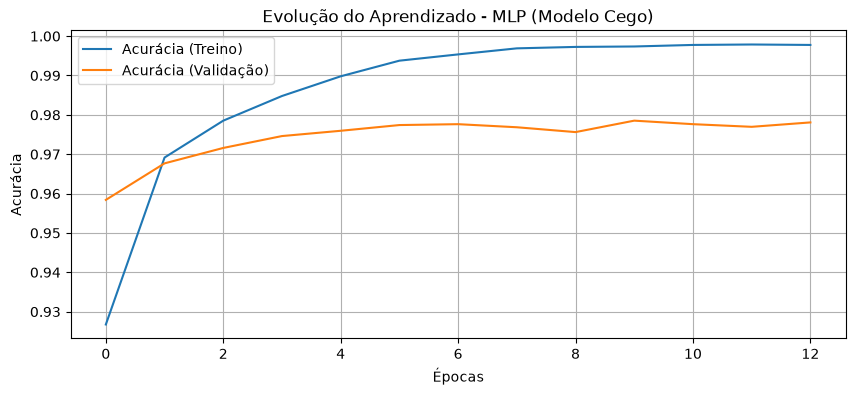

In [12]:
print("--- FASE 5.1: CLASS MASKING (Ocultando Dígitos 4 e 7) ---")

# Implementando semente de aleatoriedade para fixar logs de treinamento e gráfico

tf.keras.backend.clear_session()    # Limpa resquícios matemáticos de treinos anteriores na memória do notebook
random.seed(42)                     # Trava o gerador nativo do Python
np.random.seed(42)                  # Trava o gerador do NumPy
tf.random.set_seed(42)              # Trava o gerador do TensorFlow

# 1. Aplicação da Máscara Booleana no Dataset de Treino
mascara_treino = (y_train != 4) & (y_train != 7)

X_train_mascarado = X_train_norm[mascara_treino]
y_train_mascarado = y_train[mascara_treino]

print(f"Tamanho do treino original: {X_train_norm.shape[0]} imagens")
print(f"Tamanho do treino mascarado: {X_train_mascarado.shape[0]} imagens")
print(f"Classes presentes na nova base: {np.unique(y_train_mascarado)}\n")

# 2. Construção da Rede Neural Isolada
modelo_cego = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

modelo_cego.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# 3. Treinamento do Modelo
parada = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

print("Iniciando treinamento com as classes ocultadas...")
historico_cego = modelo_cego.fit(
    X_train_mascarado, 
    y_train_mascarado, 
    epochs=15, 
    batch_size=32,
    validation_split=0.2,
    callbacks=[parada]
)

# 4. Gráfico de Aprendizado
plt.figure(figsize=(10, 4))
plt.plot(historico_cego.history['accuracy'], label='Acurácia (Treino)')
plt.plot(historico_cego.history['val_accuracy'], label='Acurácia (Validação)')
plt.title('Evolução do Aprendizado - MLP (Modelo Cego)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

Porque a cada treinamento da rede neural, os logs são diferentes?

Na programação tradicional, esperamos um comportamento estritamente determinístico, mas as Redes Neurais operam com matemática estocástica (baseada em variáveis aleatórias) por design.

A Origem da Aleatoriedade: Sempre que você recria a estrutura do modelo, o Keras sorteia números aleatórios para preencher os "pesos iniciais" de todos os 128 neurônios. Além disso, o otimizador Adam embaralha a ordem de leitura das imagens a cada época. Como o ponto de partida e a ordem dos dados mudam, a rede nunca percorre a exata mesma rota de aprendizado duas vezes.

Nesse treinamento utilizou-se semente de aleatoriedade para fixar os parâmetros de treino. Esse artifício é útil em ambientes acadêmicos ou relatórios, no qual é preciso reprodutibilidade absoluta (mesmo gráfico e número de épocas toda vez que a célula é executada).

<br>

### Fase 5.2 - Teste de Generalização Extrema (Inferência OOD)

<br>

--- FASE 5.2: TESTE DE GENERALIZAÇÃO EXTREMA (OOD) ---
Total de imagens OOD (apenas 4 e 7): 2824
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


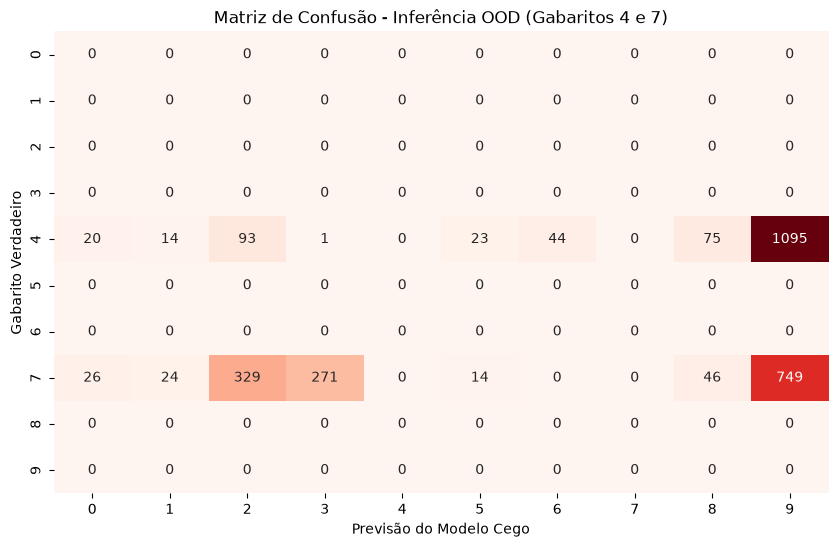

In [13]:
print("--- FASE 5.2: TESTE DE GENERALIZAÇÃO EXTREMA (OOD) ---")

# 1. Isolando exclusivamente os dígitos 4 e 7 no conjunto de TESTE
mascara_teste_ood = (y_test == 4) | (y_test == 7)
X_teste_ood = X_test_norm[mascara_teste_ood]
y_teste_ood = y_test[mascara_teste_ood]

print(f"Total de imagens OOD (apenas 4 e 7): {X_teste_ood.shape[0]}")

# 2. Forçando o modelo a classificar o que nunca viu
previsoes_ood_prob = modelo_cego.predict(X_teste_ood)
y_pred_ood = np.argmax(previsoes_ood_prob, axis=1)

# 3. Construção da Matriz de Confusão (fixando os eixos de 0 a 9)
matriz_ood = confusion_matrix(y_teste_ood, y_pred_ood, labels=range(10))

plt.figure(figsize=(10, 6))
# Usando um mapa de calor vermelho para destacar que tudo aqui é um "erro" forçado
sns.heatmap(matriz_ood, annot=True, fmt='d', cmap='Reds', cbar=False, 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusão - Inferência OOD (Gabaritos 4 e 7)')
plt.ylabel('Gabarito Verdadeiro')
plt.xlabel('Previsão do Modelo Cego')
plt.show()

Análise de Generalização Extrema (Inferência OOD)

- Reação ao Desconhecido: O modelo clássico não possui a capacidade intrínseca de dizer "não sei" ou "não reconheço". Ao ser forçado a classificar imagens cujos padrões morfológicos foram amputados do seu treinamento, ele varre a imagem em busca de características geométricas parciais (retas, ângulos, intersecções) e força um encaixe na categoria conhecida que for morfologicamente "menos errada".

- Mapeamento de Classes Atribuídas:

    - O dígito 4 foi esmagadoramente classificado como 9 (1.095 vezes). Isso ocorre porque a caligrafia do 4 (especialmente com o laço superior fechado) compartilha a mesma densidade de pixels no quadrante superior e a haste vertical direita que compõem a anatomia de um 9.

    - O dígito 7 gerou uma confusão mais fragmentada, sendo classificado majoritariamente como 9 (749 vezes), seguido pelo 2 (329 vezes) e pelo 3 (271 vezes). O compartilhamento do traço horizontal forte no topo e a linha descendente diagonal disparam a ativação dos neurônios que aprenderam a reconhecer as silhuetas do 2 e do 3.

- O Fenômeno da Falsa Certeza (Overconfidence): Este teste escancara uma falha de design em redes neurais de classificação fechada. A última camada da rede utiliza a função matemática Softmax, que obriga a soma de todas as saídas a ser exatamente 100% (1.0). Como a rede foi podada e só conhece 8 opções matemáticas, ela distribui esses 100% entre elas. Mesmo que um dígito 4 pareça um ruído alienígena para o modelo, se a classe 9 tiver a maior semelhança residual (digamos, 15% de compatibilidade geométrica), a Softmax distorce e infla esse número, entregando a predição com 99% de confiança. É uma falsa certeza gerada pela ausência estrutural de uma classe de escape (como "Desconhecido" ou "Out-of-Distribution").

<br>

### Fase 5.3 - Inferência com Imagens Manuscritas Próprias

<br>

--- INFERÊNCIA COM IMAGEM PRÓPRIA ---


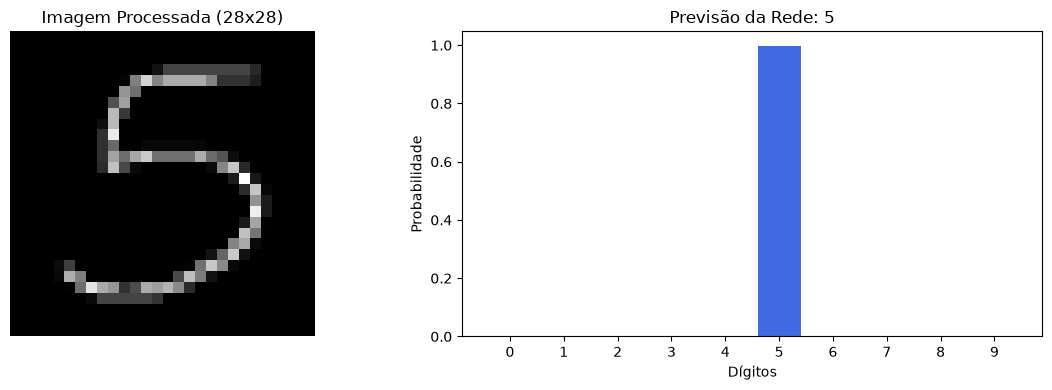

In [35]:

print("--- INFERÊNCIA COM IMAGEM PRÓPRIA ---")

def processar_imagem_mnist(caminho_imagem, fundo_branco=False):
    # 1. Conversão para escala de cinza
    img = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Imagem não encontrada no caminho: {caminho_imagem}")
        
    # 2. Inversão de cores (necessário se desenhou no papel branco)
    if fundo_branco:
        img = cv2.bitwise_not(img)
        
    # Filtro para remover ruídos e sombras fracas
    _, img_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    
    # 3. Centralização por Bounding Box (recorta apenas a área onde há tinta)
    coords = cv2.findNonZero(img_thresh)
    x, y, w, h = cv2.boundingRect(coords)
    img_recortada = img_thresh[y:y+h, x:x+w]
    
    # Adiciona uma borda preta de 20% (padrão do MNIST para o dígito não tocar os cantos)
    margem = int(max(w, h) * 0.2)
    img_borda = cv2.copyMakeBorder(img_recortada, margem, margem, margem, margem, cv2.BORDER_CONSTANT, value=0)
    
    # 4. Redimensionamento e Normalização
    img_28x28 = cv2.resize(img_borda, (28, 28), interpolation=cv2.INTER_AREA)
    img_norm = img_28x28.astype('float32') / 255.0
    
    # Achatamento para o formato (1, 784) que a Rede Neural exige
    vetor_final = img_norm.reshape(1, 784)
    return img_28x28, vetor_final

# Mude para True se você tirou foto de um papel branco
USOU_PAPEL_BRANCO = True
caminho = 'minhas_imagens/5_WhatsApp Image 2026-09-10 at 20.30.39.jpeg' # Ajuste para o nome do seu arquivo

try:
    img_visualizacao, input_rede = processar_imagem_mnist(caminho, fundo_branco=USOU_PAPEL_BRANCO)
    
    # Realiza a predição usando a Rede Neural original (completa)
    probabilidades = modelo_mlp.predict(input_rede, verbose=0)[0]
    digito_vencedor = np.argmax(probabilidades)
    
    # Plota a Imagem Processada vs. Gráfico de Probabilidades
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.imshow(img_visualizacao, cmap='gray')
    ax1.set_title("Imagem Processada (28x28)")
    ax1.axis('off')
    
    ax2.bar(range(10), probabilidades, color='royalblue')
    ax2.set_xticks(range(10))
    ax2.set_title(f"Previsão da Rede: {digito_vencedor}")
    ax2.set_ylabel("Probabilidade")
    ax2.set_xlabel("Dígitos")
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Erro: {e}")

--- INFERÊNCIA EM LOTE COM DETECÇÃO AUTOMÁTICA ---


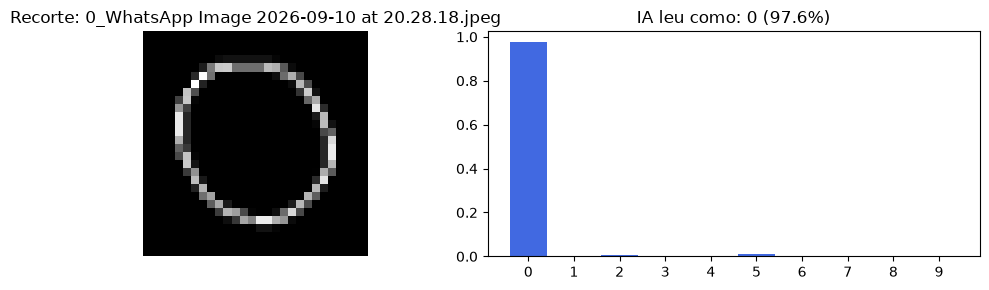

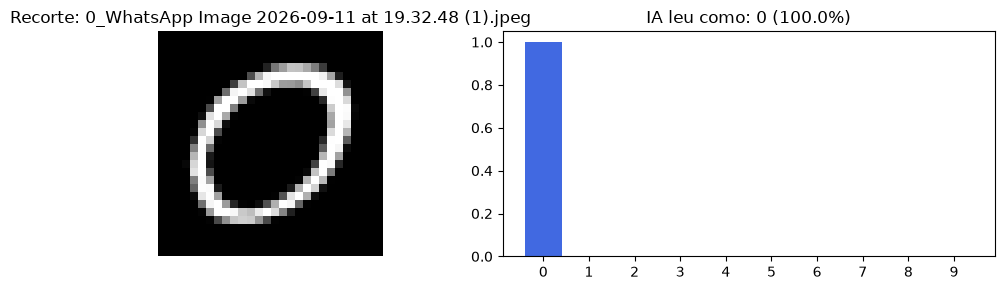

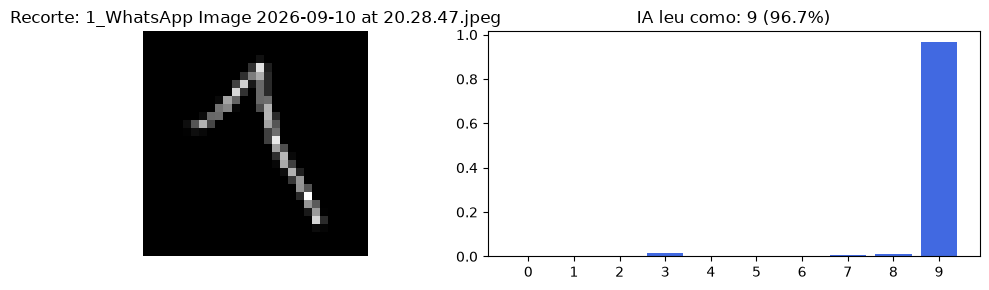

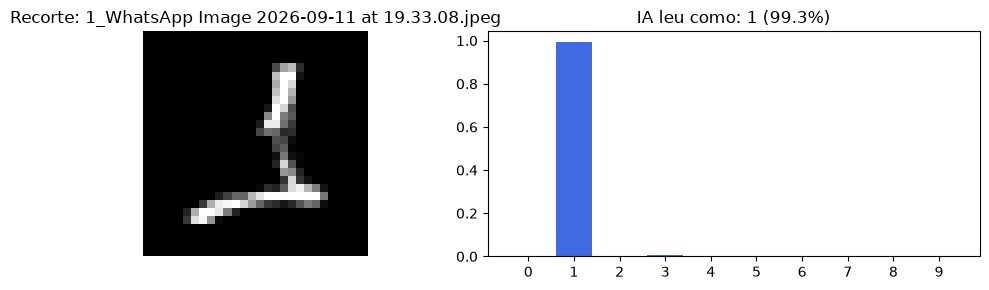

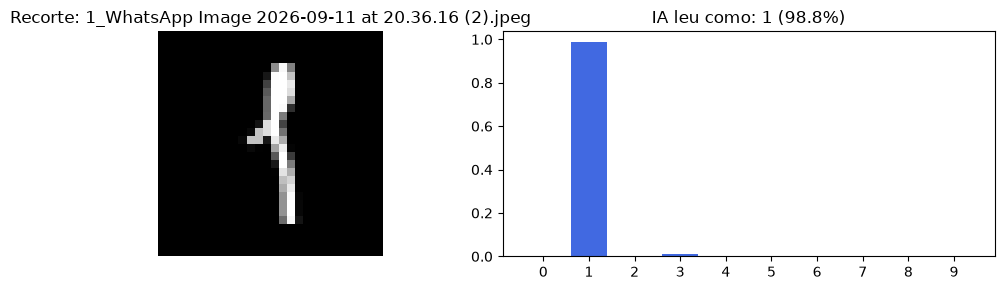

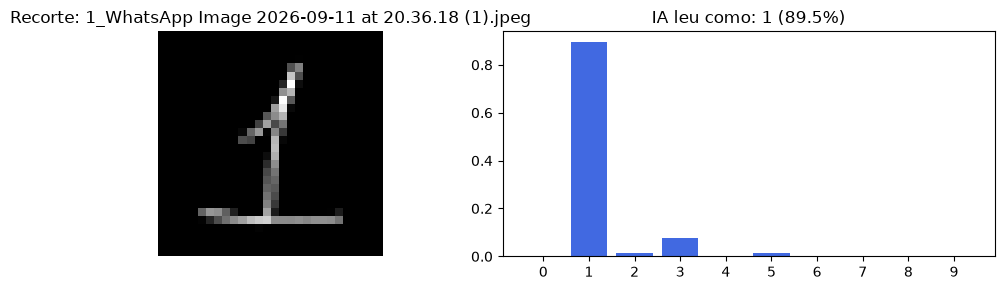

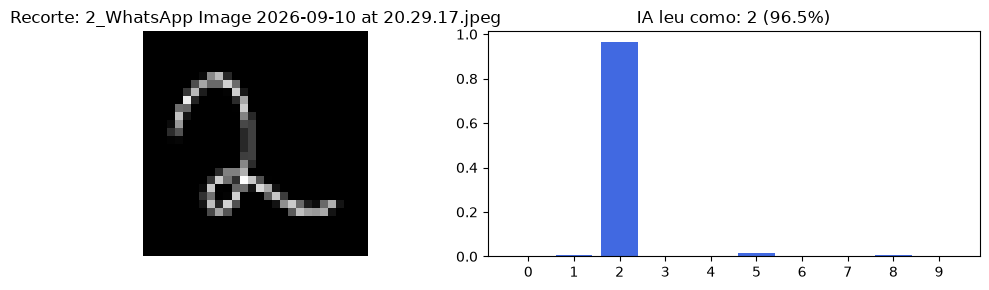

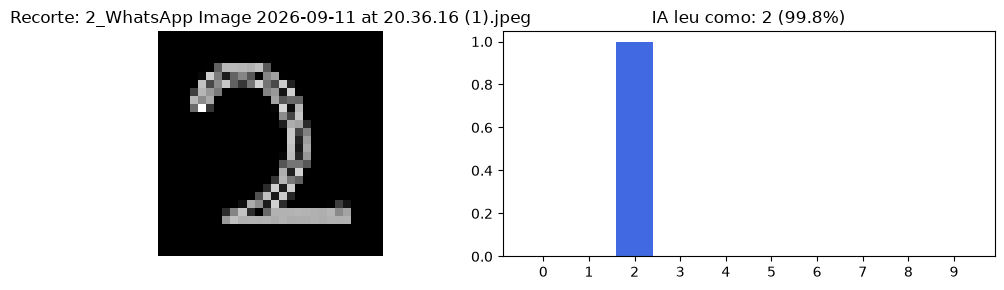

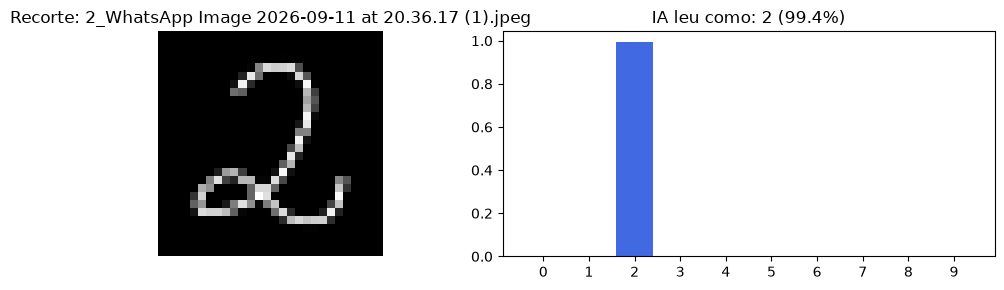

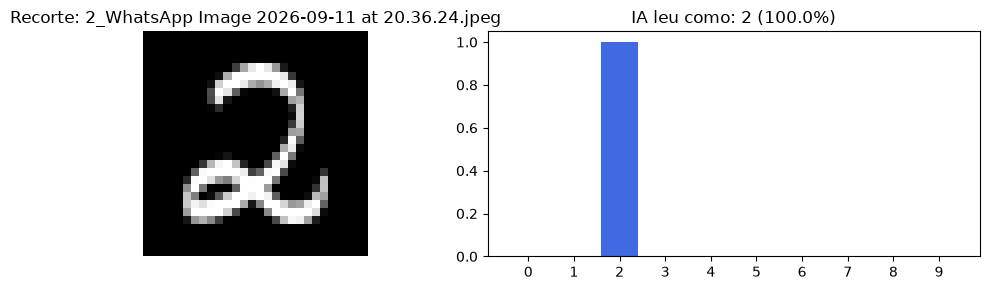

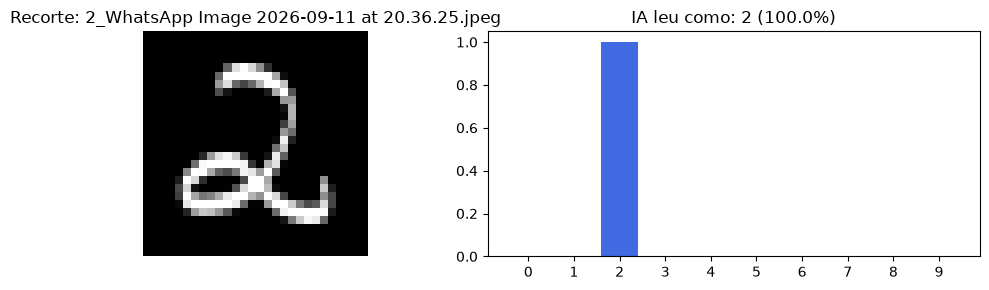

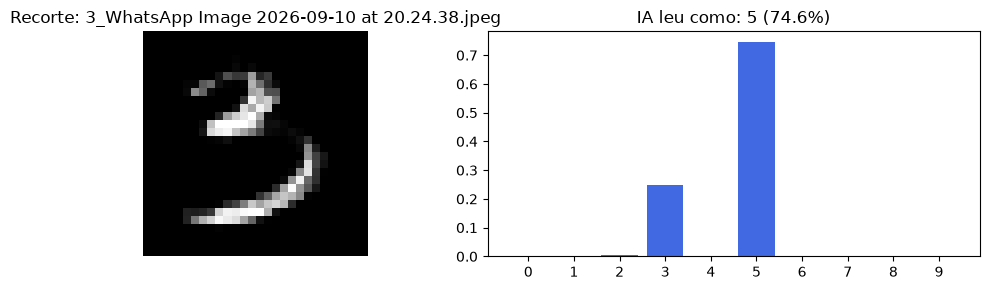

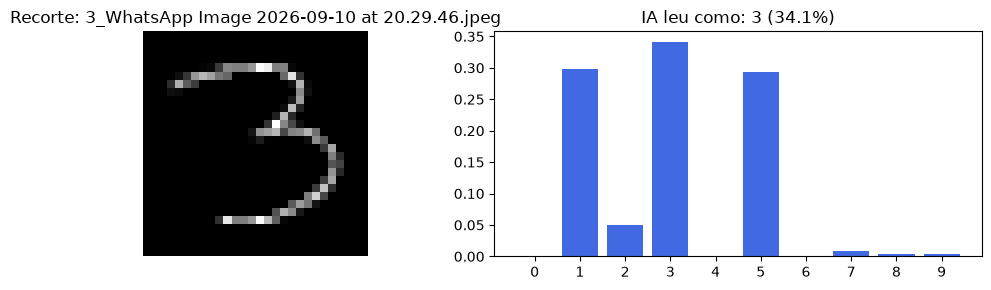

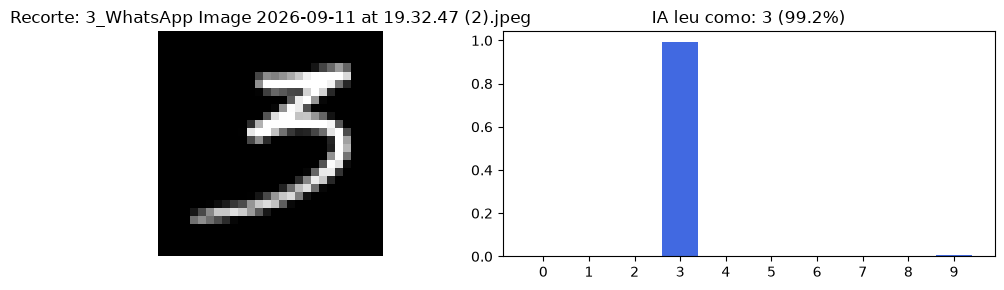

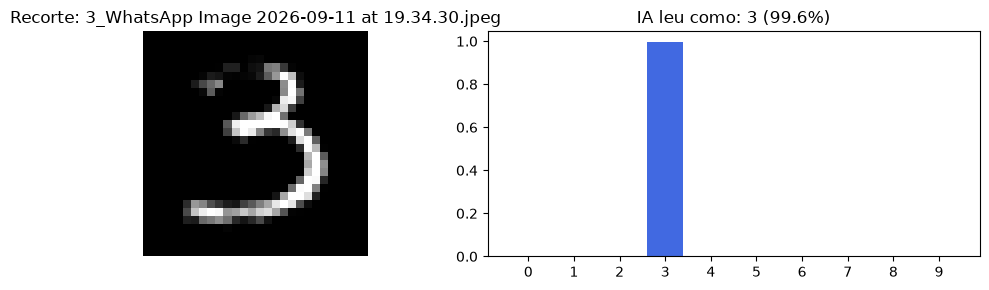

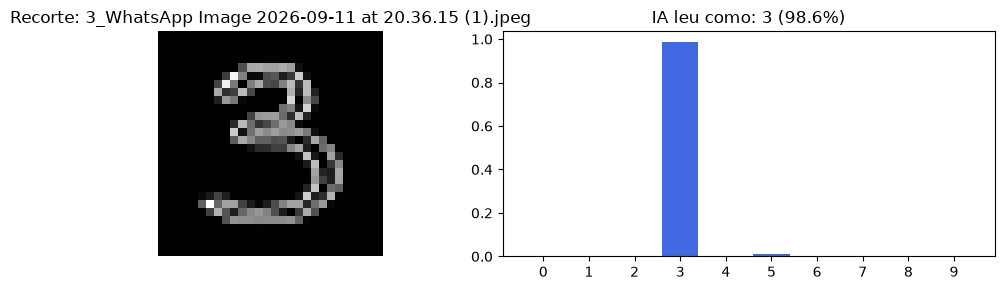

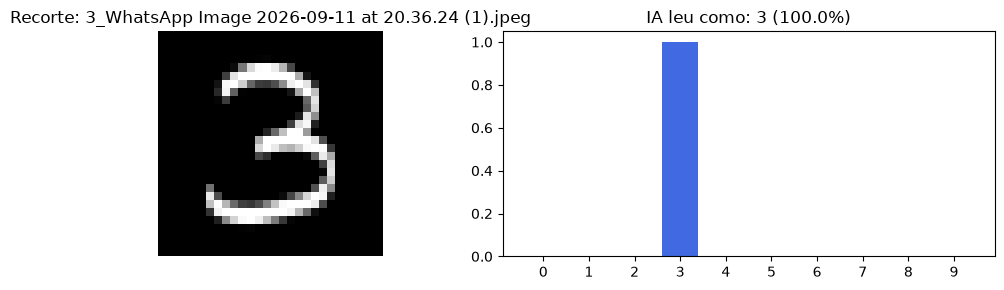

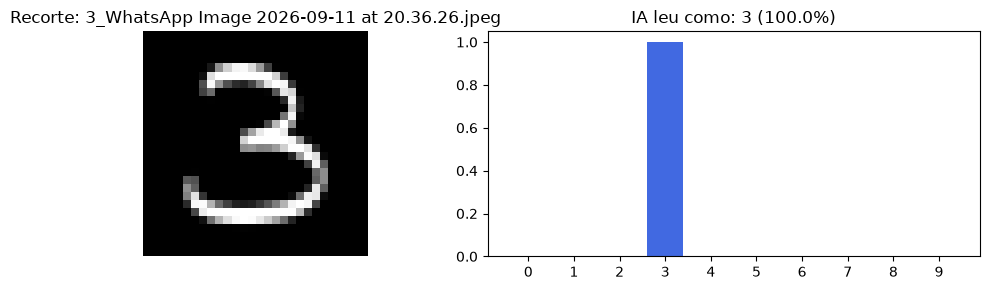

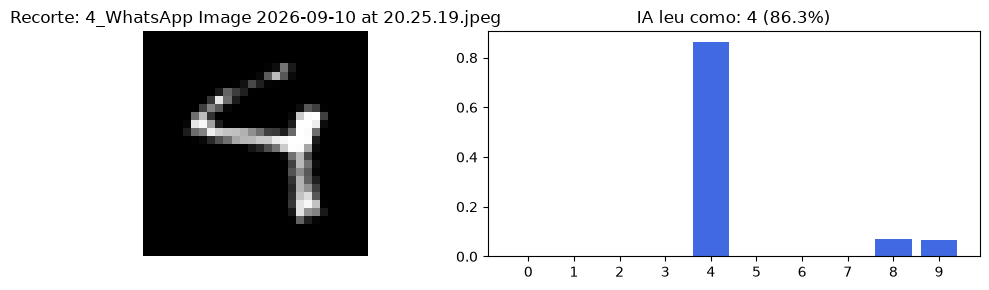

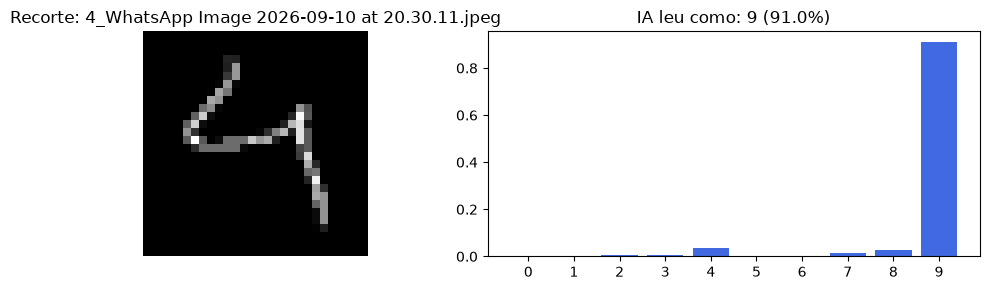

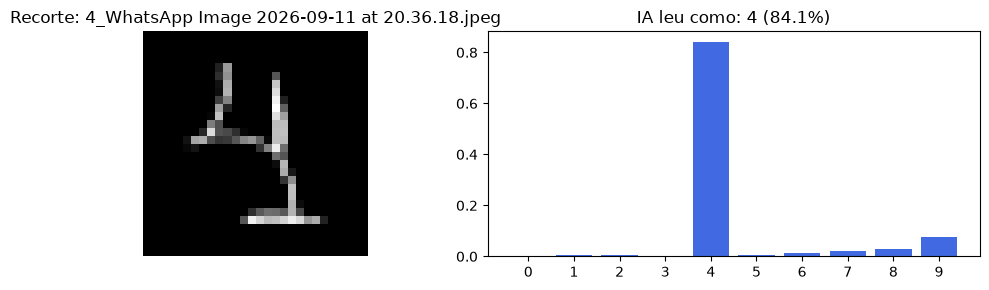

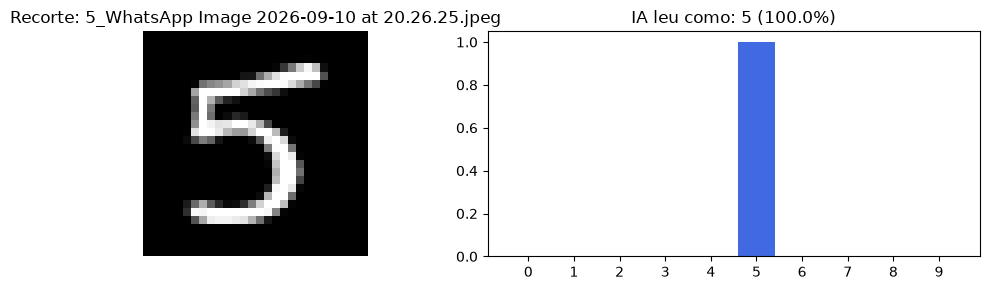

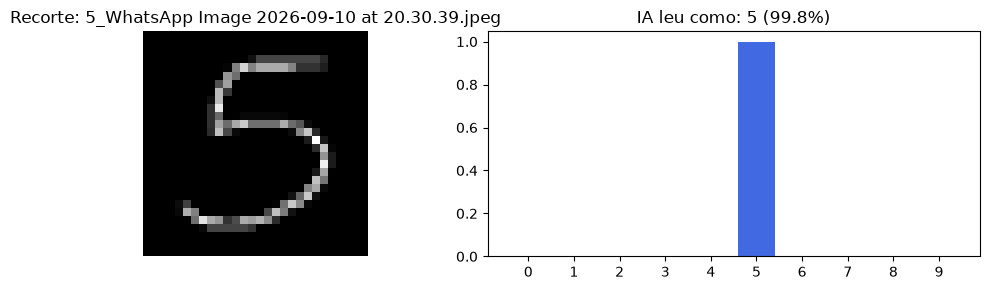

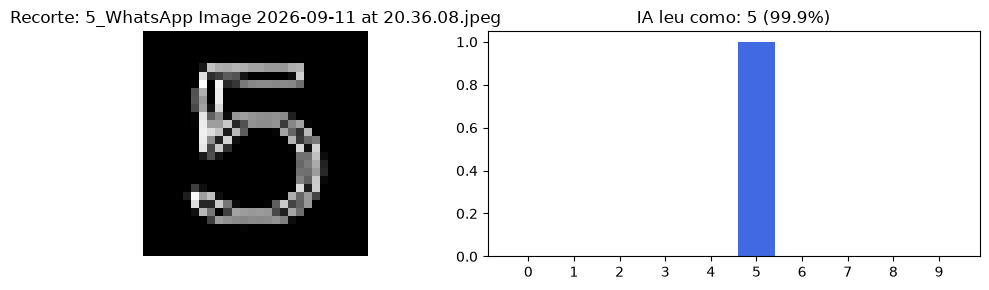

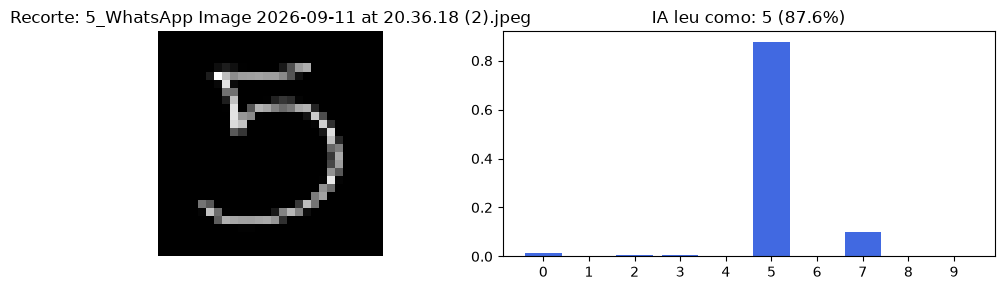

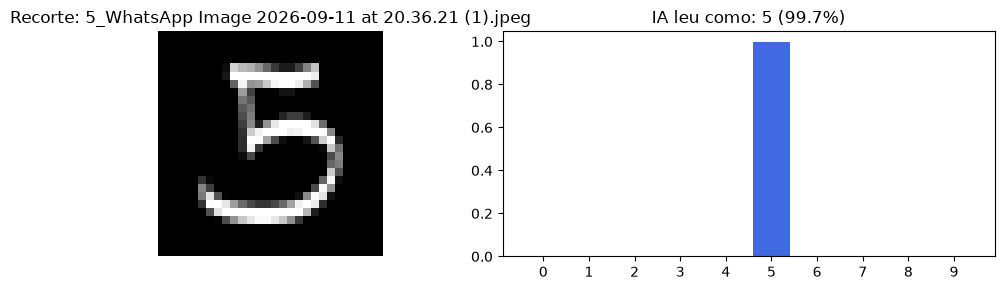

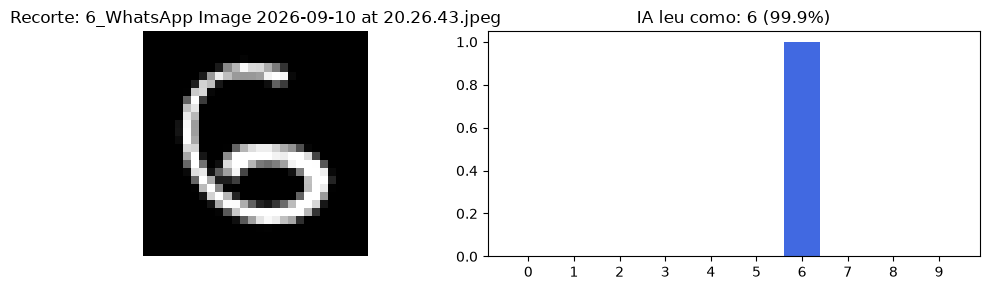

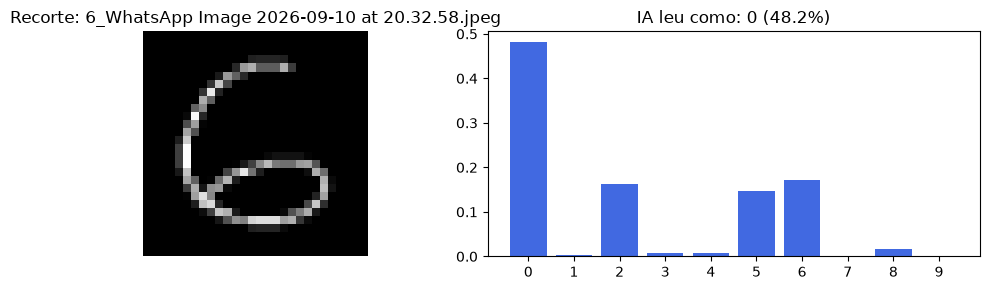

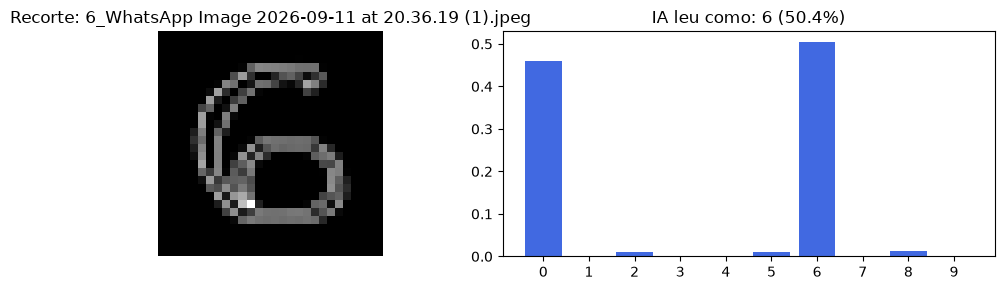

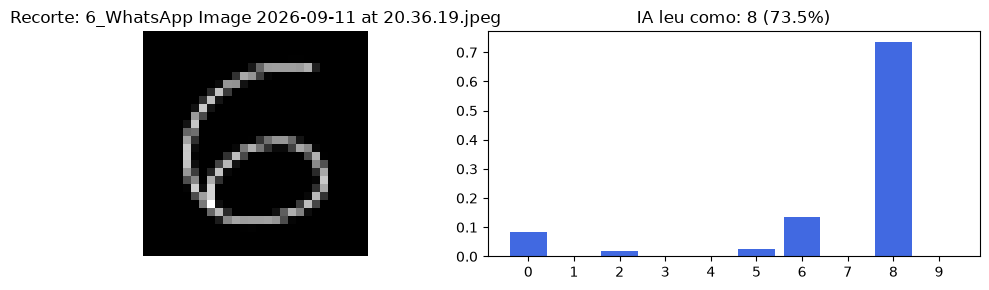

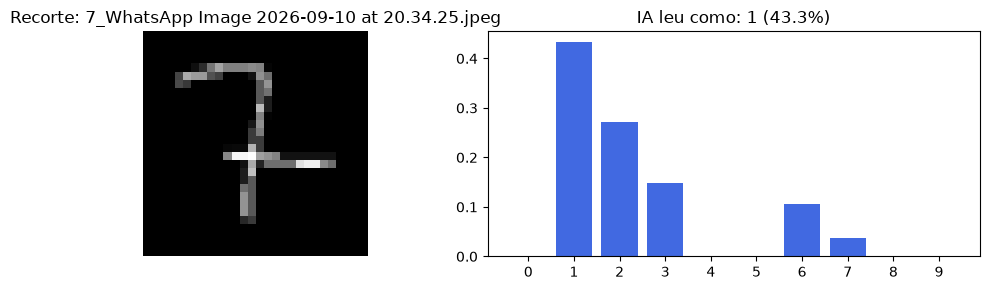

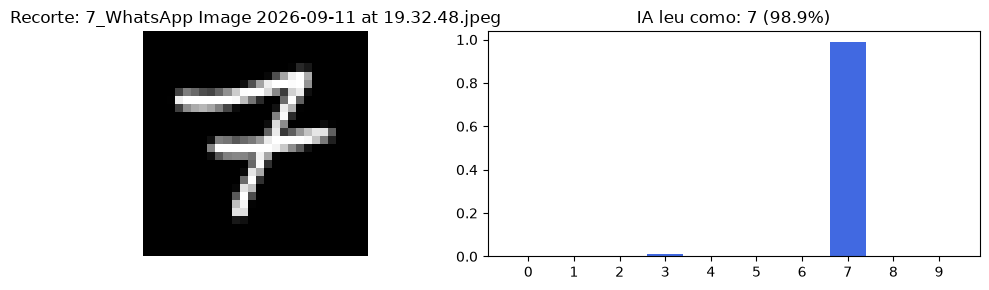

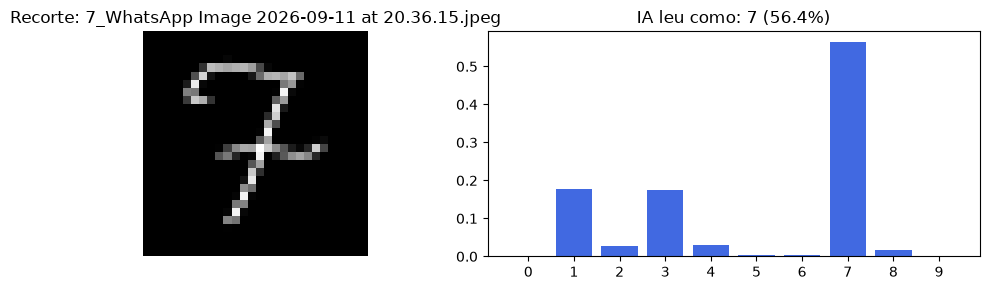

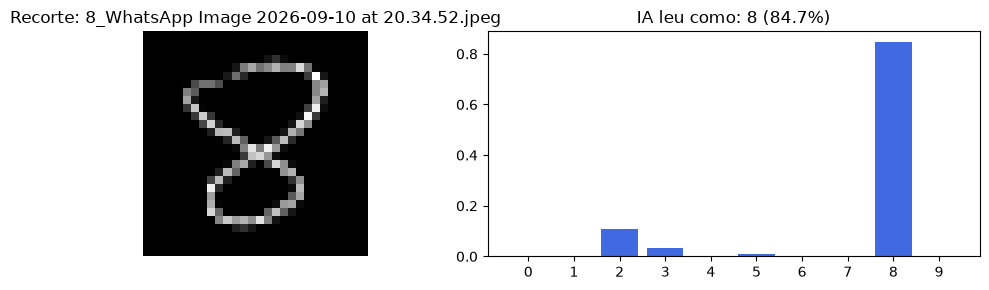

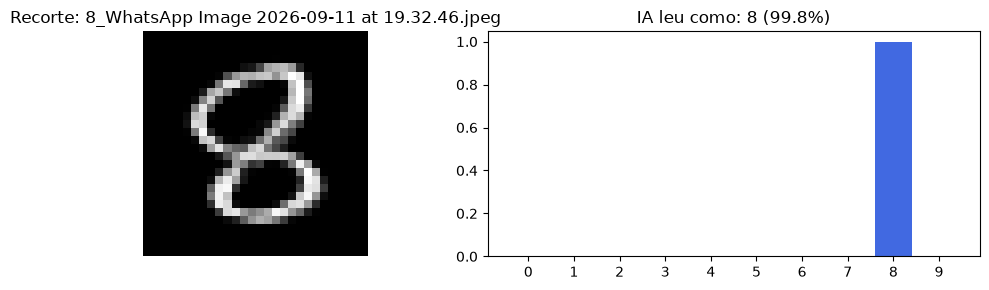

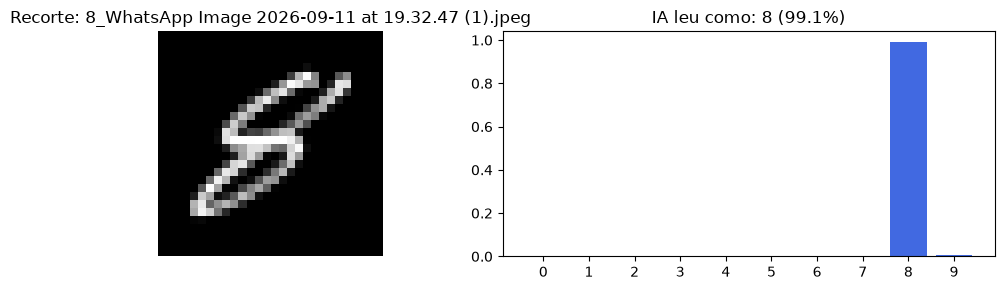

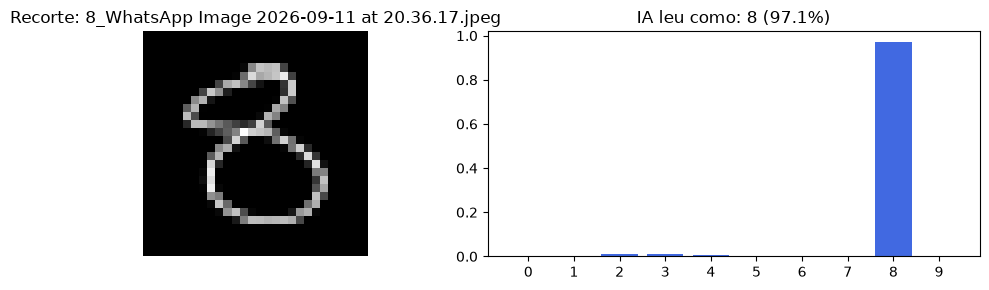

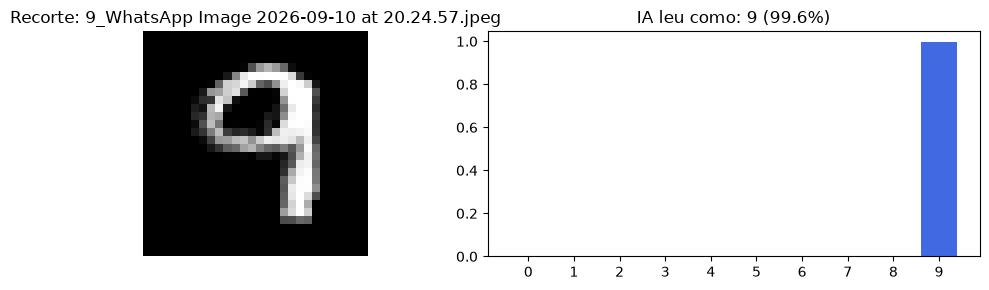

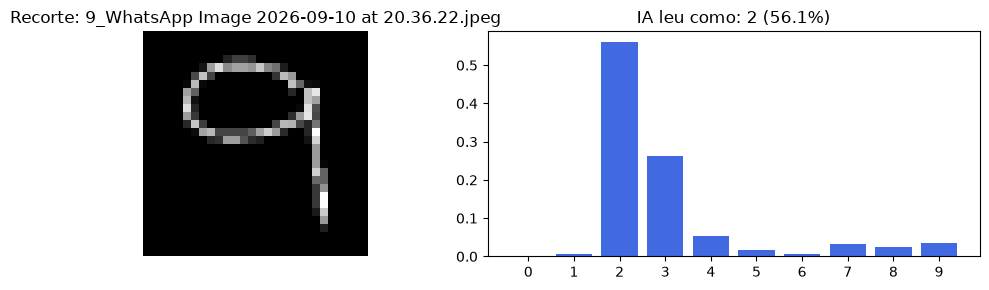

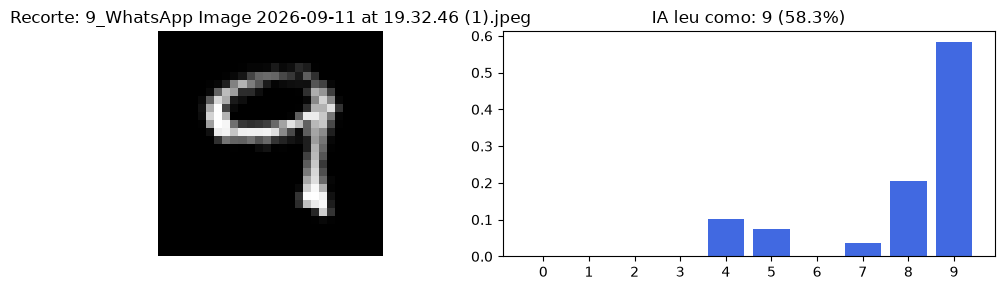

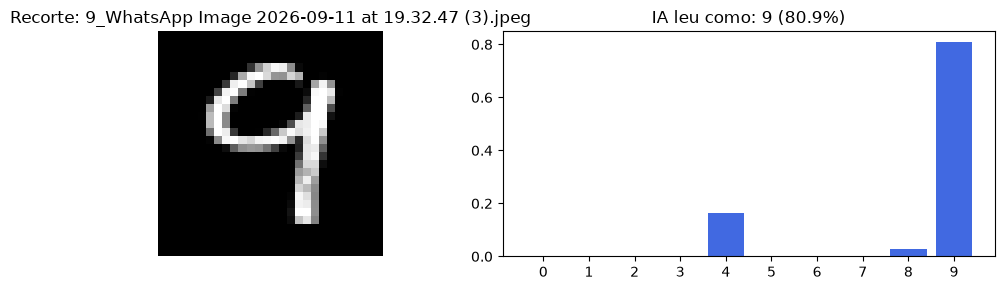

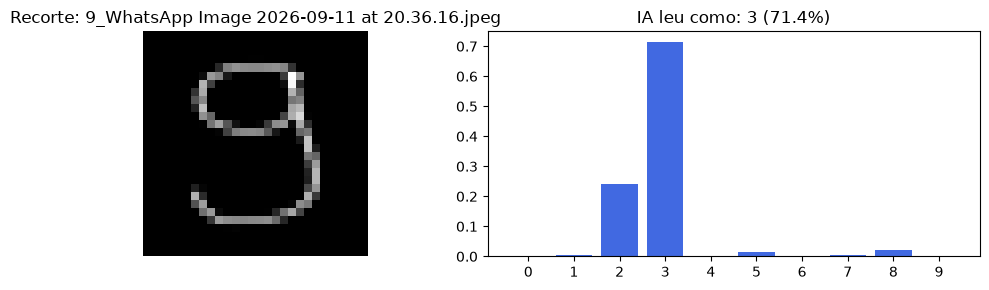

In [43]:

print("--- INFERÊNCIA EM LOTE COM DETECÇÃO AUTOMÁTICA ---")

def processar_imagem_automatica(caminho_imagem):
    # 1. Leitura em escala de cinza
    img = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None
        
    # 2. Detecção Automática de Fundo (Visão Computacional)
    # Analisamos os 4 cantos extremos da imagem. Se a média de luz for > 127, é papel branco.
    fundo_claro = np.mean([img[0,0], img[0,-1], img[-1,0], img[-1,-1]]) > 127
    if fundo_claro:
        img = cv2.bitwise_not(img) # Inverte as cores automaticamente
        
    # 3. Filtro de Contraste e Bounding Box
    _, img_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(img_thresh)
    
    if coords is None: # Prevenção de quebra se a foto estiver vazia
        return None, None
        
    x, y, w, h = cv2.boundingRect(coords)
    img_recortada = img_thresh[y:y+h, x:x+w]
    
    # 4. Borda de segurança (20%) e Redimensionamento
    margem = int(max(w, h) * 0.2)
    img_borda = cv2.copyMakeBorder(img_recortada, margem, margem, margem, margem, cv2.BORDER_CONSTANT, value=0)
    img_28x28 = cv2.resize(img_borda, (28, 28), interpolation=cv2.INTER_AREA)
    
    # 5. Normalização e Achatamento
    img_norm = img_28x28.astype('float32') / 255.0
    vetor_final = img_norm.reshape(1, 784)
    
    return img_28x28, vetor_final

# 6. Varredura da pasta e execução em lote
pasta_imagens = 'minhas_imagens' 
arquivos = glob.glob(f"{pasta_imagens}/*.png") + glob.glob(f"{pasta_imagens}/*.jpg") + glob.glob(f"{pasta_imagens}/*.jpeg")

if not arquivos:
    print(f"Nenhuma imagem encontrada na pasta '{pasta_imagens}'.")
else:
    for caminho in arquivos:
        img_visualizacao, input_rede = processar_imagem_automatica(caminho)
        
        if img_visualizacao is None:
            print(f"Ignorando arquivo inválido ou vazio: {caminho}")
            continue
            
        # Predição com o modelo completo da Fase 4
        probabilidades = modelo_mlp.predict(input_rede, verbose=0)[0]
        digito_vencedor = np.argmax(probabilidades)
        confianca = np.max(probabilidades) * 100
        
        # Plotagem individual
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
        
        ax1.imshow(img_visualizacao, cmap='gray')
        ax1.set_title(f"Recorte: {os.path.basename(caminho)}")
        ax1.axis('off')
        
        ax2.bar(range(10), probabilidades, color='royalblue')
        ax2.set_xticks(range(10))
        ax2.set_title(f"IA leu como: {digito_vencedor} ({confianca:.1f}%)")
        
        plt.tight_layout()
        plt.show()

In [44]:
print("--- CÁLCULO DE ACURÁCIA (GLOBAL E POR DÍGITO) ---")

pasta_imagens = 'minhas_imagens' 
arquivos = glob.glob(f"{pasta_imagens}/*.png") + glob.glob(f"{pasta_imagens}/*.jpg") + glob.glob(f"{pasta_imagens}/*.jpeg")

total_imagens = 0
acertos = 0

# Contadores individuais para rastrear a performance por classe
total_por_digito = {i: 0 for i in range(10)}
acertos_por_digito = {i: 0 for i in range(10)}

if not arquivos:
    print(f"Nenhuma imagem encontrada na pasta '{pasta_imagens}'.")
else:
    for caminho in arquivos:
        nome_arquivo = os.path.basename(caminho)
        gabarito_str = nome_arquivo[0]
        
        # Ignora arquivos que não começam com número
        if not gabarito_str.isdigit():
            print(f"Ignorando '{nome_arquivo}': adicione o dígito no início do nome.")
            continue
            
        gabarito_verdadeiro = int(gabarito_str)
        img_visualizacao, input_rede = processar_imagem_automatica(caminho)
        
        if input_rede is None:
            print(f"Falha ao processar a imagem: {nome_arquivo}")
            continue
            
        probabilidades = modelo_mlp.predict(input_rede, verbose=0)[0]
        previsao = np.argmax(probabilidades)
        
        # Atualização das métricas
        total_imagens += 1
        total_por_digito[gabarito_verdadeiro] += 1
        
        if previsao == gabarito_verdadeiro:
            acertos += 1
            acertos_por_digito[gabarito_verdadeiro] += 1
            status = "✅ ACERTO"
        else:
            status = "❌ ERRO"
            
        print(f"Arquivo: {nome_arquivo:20} | Previsão: {previsao} | Gabarito: {gabarito_verdadeiro} | {status}")

    # Impressão do Relatório Final
    if total_imagens > 0:
        acuracia_global = (acertos / total_imagens) * 100
        
        print("\n" + "="*40)
        print("RELATÓRIO DE DESEMPENHO")
        print("="*40)
        print(f"Total de Imagens: {total_imagens}")
        print(f"Acertos Globais: {acertos}")
        print(f"Acurácia Global: {acuracia_global:.2f}%\n")
        
        print("--- Detalhamento por Dígito ---")
        for digito in range(10):
            total_d = total_por_digito[digito]
            if total_d > 0:
                acertos_d = acertos_por_digito[digito]
                acc_d = (acertos_d / total_d) * 100
                print(f"Dígito {digito}: {acc_d:6.2f}% ({acertos_d}/{total_d})")
        print("="*40)

--- CÁLCULO DE ACURÁCIA (GLOBAL E POR DÍGITO) ---
Arquivo: 0_WhatsApp Image 2026-09-10 at 20.28.18.jpeg | Previsão: 0 | Gabarito: 0 | ✅ ACERTO
Arquivo: 0_WhatsApp Image 2026-09-11 at 19.32.48 (1).jpeg | Previsão: 0 | Gabarito: 0 | ✅ ACERTO
Arquivo: 1_WhatsApp Image 2026-09-10 at 20.28.47.jpeg | Previsão: 9 | Gabarito: 1 | ❌ ERRO
Arquivo: 1_WhatsApp Image 2026-09-11 at 19.33.08.jpeg | Previsão: 1 | Gabarito: 1 | ✅ ACERTO
Arquivo: 1_WhatsApp Image 2026-09-11 at 20.36.16 (2).jpeg | Previsão: 1 | Gabarito: 1 | ✅ ACERTO
Arquivo: 1_WhatsApp Image 2026-09-11 at 20.36.18 (1).jpeg | Previsão: 1 | Gabarito: 1 | ✅ ACERTO
Arquivo: 2_WhatsApp Image 2026-09-10 at 20.29.17.jpeg | Previsão: 2 | Gabarito: 2 | ✅ ACERTO
Arquivo: 2_WhatsApp Image 2026-09-11 at 20.36.16 (1).jpeg | Previsão: 2 | Gabarito: 2 | ✅ ACERTO
Arquivo: 2_WhatsApp Image 2026-09-11 at 20.36.17 (1).jpeg | Previsão: 2 | Gabarito: 2 | ✅ ACERTO
Arquivo: 2_WhatsApp Image 2026-09-11 at 20.36.24.jpeg | Previsão: 2 | Gabarito: 2 | ✅ ACERTO
Ar

Conclusão Técnica - Fase 5.3: Inferência no Mundo Real

- O Viés da Espessura (Densidade de Pixels): O dataset MNIST original foi construído com dígitos escritos por funcionários do censo americano usando traços marcados e espessos. A sua Rede Neural não aprendeu a ideia abstrata de "um número", ela mapeou a densidade de pixels brancos em uma grade. Quando você submete um traço de caneta fina, a redução agressiva para a resolução de 28x28 pixels causa perda de informação (anti-aliasing). A linha fica tão rala que a matriz de entrada não atinge o limiar numérico necessário para ativar os neurônios da função ReLU, resultando em previsões erradas.

- Desempenho Geral (80,95%): Atingir mais de 80% de acerto em imagens brutas tiradas do celular, com diferentes fundos e iluminações, é um excelente resultado para um modelo MLP simples. A rede atingiu 100% de precisão nos dígitos 0, 2, 5 e 8, provando que as curvas e ângulos agudos dessas classes são morfologicamente fortes o suficiente para sobreviver ao redimensionamento, independentemente da foto.

- Mapeamento de Erros Críticos:

    - O dígito 6 apresentou a maior vulnerabilidade (50% de acerto), sendo confundido com 0 e 8. Em traços finos, a redução de resolução costuma "fechar" o buraco superior do 6 (transformando-o em um 8) ou apagar a perna central (transformando-o em um 0).

    - O dígito 9 (60%) e o 4 (66,67%) mantiveram o exato mesmo padrão de confusão que descobrimos matematicamente lá na Fase 5.2 (OOD). O modelo tem uma deficiência estrutural crônica para separar a haste vertical do 4 e a cabeça fechada do 9 quando o traço não é perfeito.

    - O dígito 7 (66,67%) foi confundido com o 1, um clássico erro topológico quando o corte horizontal do 7 não é espesso o suficiente para diferenciar da haste reta do 1.

Possibilidade de Melhoria do Modelo:

Para resolver o problema da caneta fina em projetos de nível de produção, a solução seria retornar à Fase 3 e aplicar Data Augmentation: afinar, engrossar e rotacionar as imagens originais do MNIST artificialmente antes do treino, forçando o modelo a aprender a silhueta, e não a grossura da tinta.